# 사과 DL 신선도 판별 프로세스 시각화 노트

이 노트는 `DL_apple_freshness_full_process_report.md`를 설명할 때 사용할 시각화 자료를 만드는 보조 노트입니다.

학습을 다시 수행하지 않고, 현재 리포트와 모델 평가 결과를 기반으로 다음 자료를 생성합니다.

- 데이터 폴더 구조
- 라벨링 JSON 사용 방식
- 등급 라벨과 view 라벨 매핑
- `group_no` 기준 split과 데이터 누수 방지
- top 쏠림과 balanced train 전략
- 최종 모델 라우팅 구조
- 실패 실험과 최종 모델 비교
- 최종 confusion matrix와 class별 성능
- 신선도 점수/판정/API 앱 분기 흐름

## 1. 기본 설정

Kaggle/로컬에서 바로 실행 가능하도록 `matplotlib` 중심으로 작성했습니다. 실행하면 `Note/visuals/` 폴더에 PNG 파일이 저장됩니다.

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import numpy as np
import pandas as pd
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

OUTPUT_DIR = Path('visuals')
OUTPUT_DIR.mkdir(exist_ok=True)

font_candidates = ['Malgun Gothic', 'AppleGothic', 'NanumGothic', 'Noto Sans CJK KR', 'DejaVu Sans']
available_fonts = {f.name for f in fm.fontManager.ttflist}
for font_name in font_candidates:
    if font_name in available_fonts:
        plt.rcParams['font.family'] = font_name
        break

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 130
plt.rcParams['savefig.bbox'] = 'tight'

COLORS = {
    'blue': '#1565C0', 'light_blue': '#90CAF9',
    'green': '#2E7D32', 'light_green': '#A5D6A7',
    'orange': '#EF6C00', 'light_orange': '#FFCC80',
    'red': '#C62828', 'purple': '#6A1B9A',
    'gray': '#616161', 'light_gray': '#EEEEEE'
}

def savefig(name):
    path = OUTPUT_DIR / name
    plt.savefig(path)
    print(f'saved: {path}')

def add_box(ax, text, x, y, w, h, color, text_color='white', fontsize=10):
    patch = FancyBboxPatch((x-w/2, y-h/2), w, h, boxstyle='round,pad=0.018', fc=color, ec='white', lw=2)
    ax.add_patch(patch)
    ax.text(x, y, text, ha='center', va='center', color=text_color, fontsize=fontsize, weight='bold')

def add_arrow(ax, start, end, color='#444'):
    ax.add_patch(FancyArrowPatch(start, end, arrowstyle='-|>', mutation_scale=14, lw=1.5, color=color))

## 2. 데이터 폴더 구조

원본 데이터는 `Training`과 `Validation`으로 나뉘고, 각 split 내부가 라벨링 JSON과 원천 이미지로 나뉩니다. 최종 학습에서는 두 공식 split을 먼저 합친 뒤 `group_no` 기준으로 다시 분리했습니다.

saved: visuals\01_data_folder_structure.png


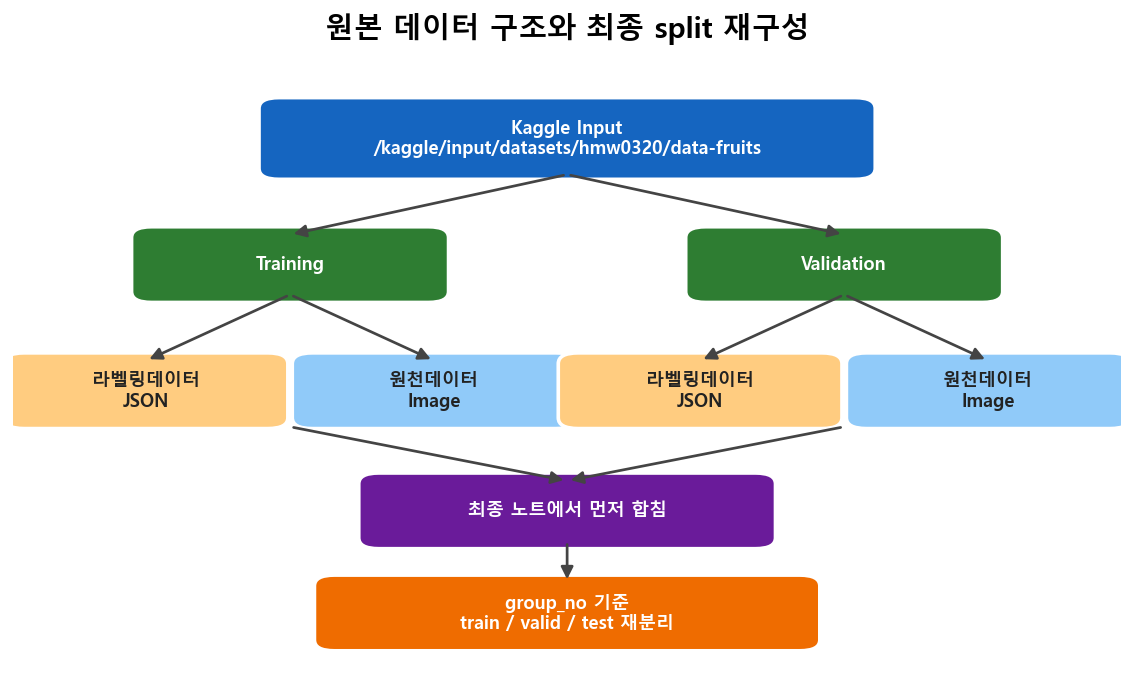

In [2]:
fig, ax = plt.subplots(figsize=(11, 6))
ax.axis('off')

nodes = [
    ('Kaggle Input\n/kaggle/input/datasets/hmw0320/data-fruits', 0.5, 0.88, 0.52, 0.10, COLORS['blue']),
    ('Training', 0.25, 0.67, 0.25, 0.09, COLORS['green']),
    ('Validation', 0.75, 0.67, 0.25, 0.09, COLORS['green']),
    ('라벨링데이터\nJSON', 0.12, 0.46, 0.22, 0.09, COLORS['light_orange']),
    ('원천데이터\nImage', 0.38, 0.46, 0.22, 0.09, COLORS['light_blue']),
    ('라벨링데이터\nJSON', 0.62, 0.46, 0.22, 0.09, COLORS['light_orange']),
    ('원천데이터\nImage', 0.88, 0.46, 0.22, 0.09, COLORS['light_blue']),
    ('최종 노트에서 먼저 합침', 0.5, 0.26, 0.34, 0.09, COLORS['purple']),
    ('group_no 기준\ntrain / valid / test 재분리', 0.5, 0.09, 0.42, 0.09, COLORS['orange']),
]

for label, x, y, w, h, color in nodes:
    text_color = '#222' if color in [COLORS['light_orange'], COLORS['light_blue']] else 'white'
    add_box(ax, label, x, y, w, h, color, text_color=text_color)

for start, end in [
    ((0.5, 0.82), (0.25, 0.72)), ((0.5, 0.82), (0.75, 0.72)),
    ((0.25, 0.62), (0.12, 0.51)), ((0.25, 0.62), (0.38, 0.51)),
    ((0.75, 0.62), (0.62, 0.51)), ((0.75, 0.62), (0.88, 0.51)),
    ((0.25, 0.40), (0.5, 0.31)), ((0.75, 0.40), (0.5, 0.31)),
    ((0.5, 0.21), (0.5, 0.14)),
]:
    add_arrow(ax, start, end)

ax.set_title('원본 데이터 구조와 최종 split 재구성', fontsize=16, weight='bold', pad=16)
savefig('01_data_folder_structure.png')
plt.show()

## 3. 라벨링 JSON 사용 방식

JSON은 모델 입력이 아니라 정답 라벨과 분석 기준을 만들기 위해 사용합니다. 실제 앱 추론에서는 이미지 1장만 입력됩니다.

saved: visuals\02_json_label_mapping.png


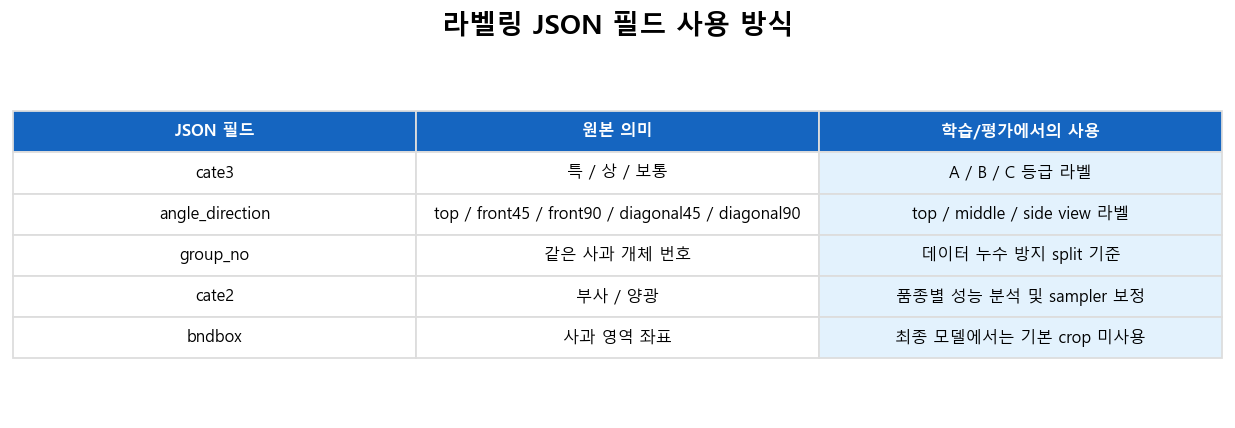

In [3]:
json_mapping = pd.DataFrame([
    ['cate3', '특 / 상 / 보통', 'A / B / C 등급 라벨'],
    ['angle_direction', 'top / front45 / front90 / diagonal45 / diagonal90', 'top / middle / side view 라벨'],
    ['group_no', '같은 사과 개체 번호', '데이터 누수 방지 split 기준'],
    ['cate2', '부사 / 양광', '품종별 성능 분석 및 sampler 보정'],
    ['bndbox', '사과 영역 좌표', '최종 모델에서는 기본 crop 미사용'],
], columns=['JSON 필드', '원본 의미', '학습/평가에서의 사용'])

fig, ax = plt.subplots(figsize=(12, 3.6))
ax.axis('off')
table = ax.table(cellText=json_mapping.values, colLabels=json_mapping.columns, loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.9)
for (row, col), cell in table.get_celld().items():
    cell.set_edgecolor('#DDDDDD')
    if row == 0:
        cell.set_facecolor(COLORS['blue'])
        cell.set_text_props(color='white', weight='bold')
    elif col == 2:
        cell.set_facecolor('#E3F2FD')
ax.set_title('라벨링 JSON 필드 사용 방식', fontsize=15, weight='bold', pad=12)
savefig('02_json_label_mapping.png')
plt.show()

## 4. 등급 라벨과 view 라벨 매핑

품질 등급은 `A/B/C`로 통일했고, 세부 각도는 앱 촬영 상황에 맞춰 `top/middle/side`로 재구성했습니다.

saved: visuals\03_label_mappings.png


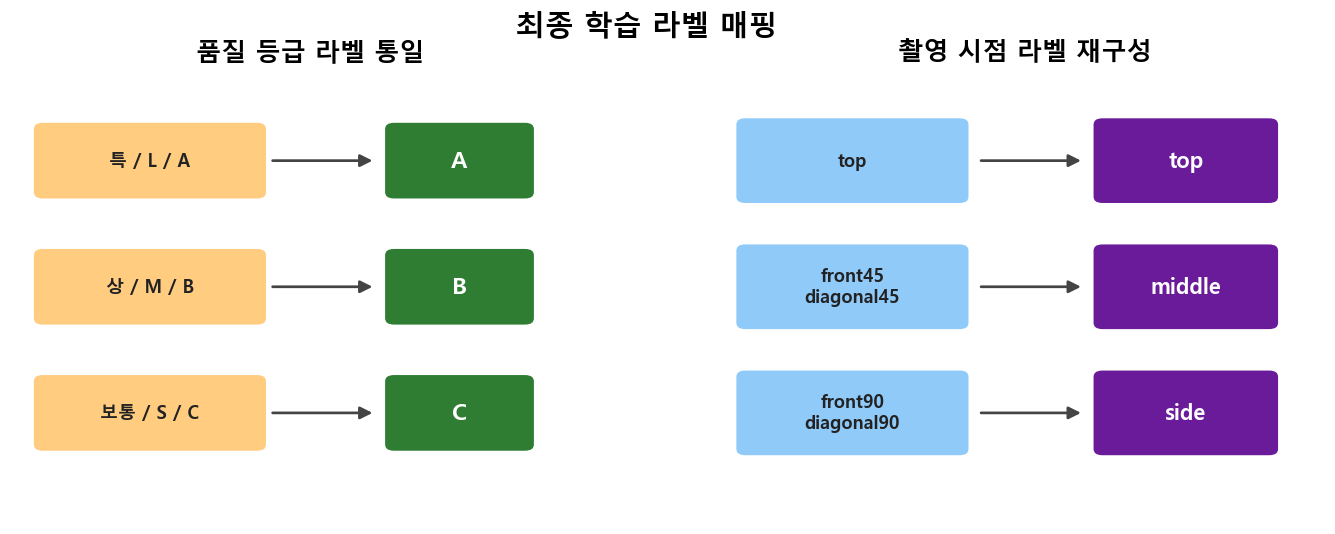

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax = axes[0]
ax.axis('off')
for i, (src, dst) in enumerate([('특 / L / A', 'A'), ('상 / M / B', 'B'), ('보통 / S / C', 'C')]):
    y = 0.8 - i * 0.28
    add_box(ax, src, 0.23, y, 0.36, 0.14, COLORS['light_orange'], text_color='#222')
    add_arrow(ax, (0.43, y), (0.61, y))
    add_box(ax, dst, 0.75, y, 0.22, 0.14, COLORS['green'], fontsize=13)
ax.set_title('품질 등급 라벨 통일', fontsize=14, weight='bold')

ax = axes[1]
ax.axis('off')
for i, (src, dst) in enumerate([('top', 'top'), ('front45\ndiagonal45', 'middle'), ('front90\ndiagonal90', 'side')]):
    y = 0.8 - i * 0.28
    add_box(ax, src, 0.21, y, 0.36, 0.16, COLORS['light_blue'], text_color='#222')
    add_arrow(ax, (0.42, y), (0.60, y))
    add_box(ax, dst, 0.77, y, 0.28, 0.16, COLORS['purple'], fontsize=12)
ax.set_title('촬영 시점 라벨 재구성', fontsize=14, weight='bold')

fig.suptitle('최종 학습 라벨 매핑', fontsize=16, weight='bold')
savefig('03_label_mappings.png')
plt.show()

## 5. `group_no` 기준 split 구조

이미지 단위 random split은 같은 사과의 다른 각도 이미지가 train과 test에 동시에 들어갈 수 있습니다. 최종 방식은 같은 사과 개체를 하나의 split에만 배치합니다.

saved: visuals\04_group_split_vs_random_split.png


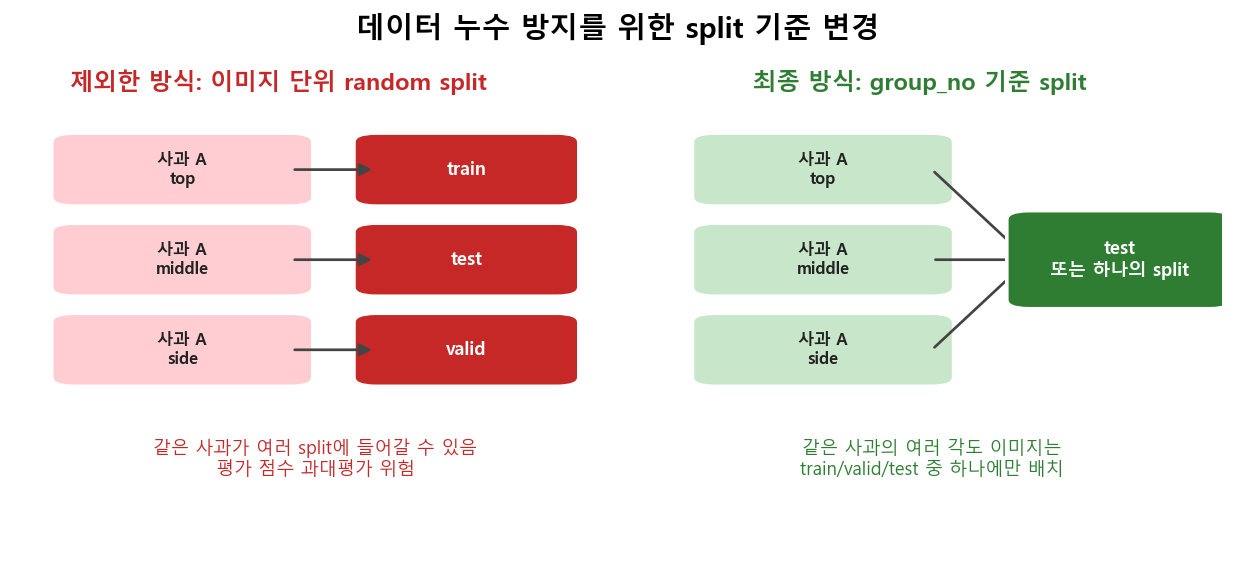

In [5]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.axis('off')

ax.text(0.22, 0.94, '제외한 방식: 이미지 단위 random split', ha='center', fontsize=13, weight='bold', color=COLORS['red'])
for i, angle in enumerate(['top', 'middle', 'side']):
    y = 0.78 - i * 0.18
    add_box(ax, f'사과 A\n{angle}', 0.14, y, 0.18, 0.11, '#FFCDD2', text_color='#222', fontsize=9)
    split = ['train', 'test', 'valid'][i]
    add_box(ax, split, 0.375, y, 0.15, 0.11, COLORS['red'])
    add_arrow(ax, (0.23, y), (0.30, y))
ax.text(0.25, 0.17, '같은 사과가 여러 split에 들어갈 수 있음\n평가 점수 과대평가 위험', ha='center', fontsize=10, color=COLORS['red'])

ax.text(0.75, 0.94, '최종 방식: group_no 기준 split', ha='center', fontsize=13, weight='bold', color=COLORS['green'])
for i, angle in enumerate(['top', 'middle', 'side']):
    y = 0.78 - i * 0.18
    add_box(ax, f'사과 A\n{angle}', 0.67, y, 0.18, 0.11, '#C8E6C9', text_color='#222', fontsize=9)
    add_arrow(ax, (0.76, y), (0.84, 0.60))
add_box(ax, 'test\n또는 하나의 split', 0.915, 0.60, 0.15, 0.16, COLORS['green'])
ax.text(0.76, 0.17, '같은 사과의 여러 각도 이미지는\ntrain/valid/test 중 하나에만 배치', ha='center', fontsize=10, color=COLORS['green'])

ax.set_title('데이터 누수 방지를 위한 split 기준 변경', fontsize=16, weight='bold', pad=12)
savefig('04_group_split_vs_random_split.png')
plt.show()

## 6. 원본 view 분포와 balanced train 전략

원본 분포는 top이 압도적으로 많습니다. 최종 노트는 train/valid/test 모두 모델별 balanced subset을 적용합니다.

saved: visuals\05_view_distribution_and_balancing.png


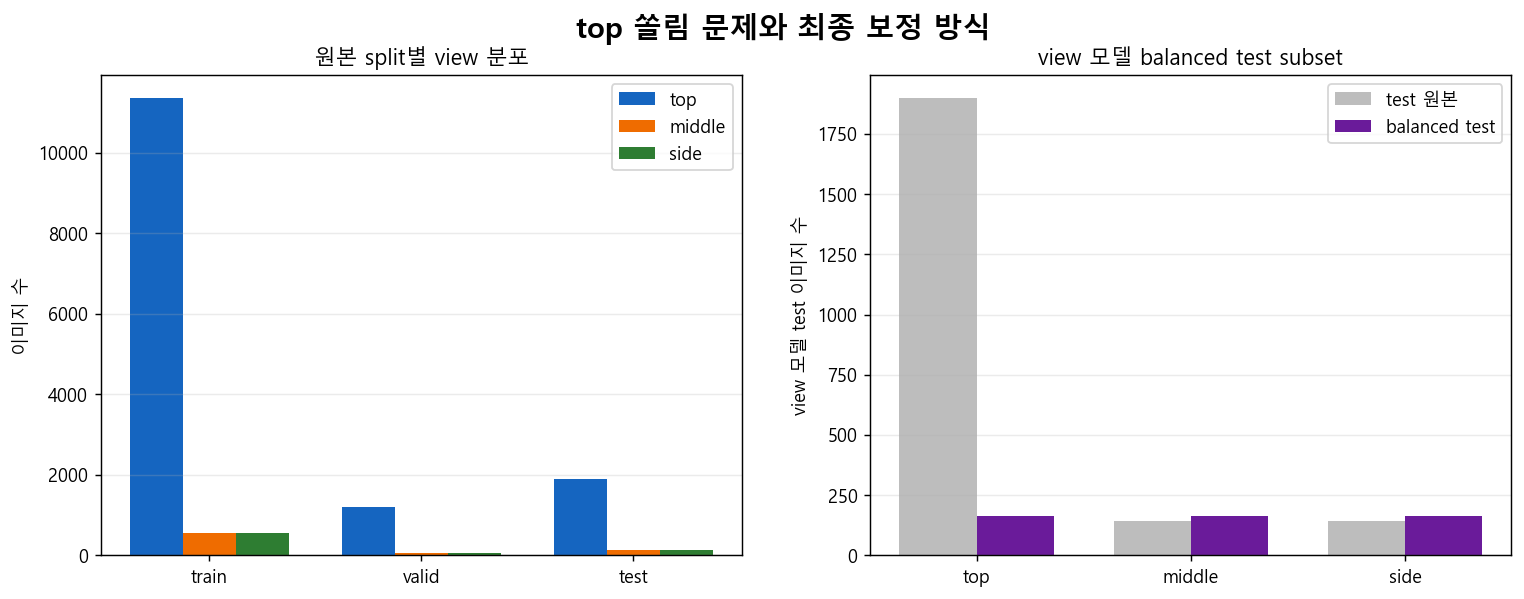

In [6]:
split_counts = pd.DataFrame({
    'split': ['train', 'valid', 'test'],
    'top': [11369, 1194, 1900],
    'middle': [565, 59, 142],
    'side': [565, 59, 142],
})
view_train_before = {'top': 1900, 'middle': 142, 'side': 142}
view_train_after = {'top': 162, 'middle': 162, 'side': 162}

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
ax = axes[0]
x = np.arange(len(split_counts['split']))
width = 0.25
for offset, label, color in [(-width, 'top', COLORS['blue']), (0, 'middle', COLORS['orange']), (width, 'side', COLORS['green'])]:
    ax.bar(x + offset, split_counts[label], width, label=label, color=color)
ax.set_xticks(x)
ax.set_xticklabels(split_counts['split'])
ax.set_ylabel('이미지 수')
ax.set_title('원본 split별 view 분포')
ax.legend()
ax.grid(axis='y', alpha=0.25)

ax = axes[1]
labels = ['top', 'middle', 'side']
x = np.arange(len(labels))
ax.bar(x - 0.18, [view_train_before[k] for k in labels], 0.36, label='test 원본', color='#BDBDBD')
ax.bar(x + 0.18, [view_train_after[k] for k in labels], 0.36, label='balanced test', color=COLORS['purple'])
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('view 모델 test 이미지 수')
ax.set_title('view 모델 balanced test subset')
ax.legend()
ax.grid(axis='y', alpha=0.25)
fig.suptitle('top 쏠림 문제와 최종 보정 방식', fontsize=16, weight='bold')
savefig('05_view_distribution_and_balancing.png')
plt.show()

## 7. 최종 모델 라우팅 구조

최종 모델은 총 4개입니다. 먼저 view 모델이 `top/middle/side`를 판단하고, 그 결과에 따라 등급 모델을 선택합니다.

saved: visuals\06_final_model_routing.png


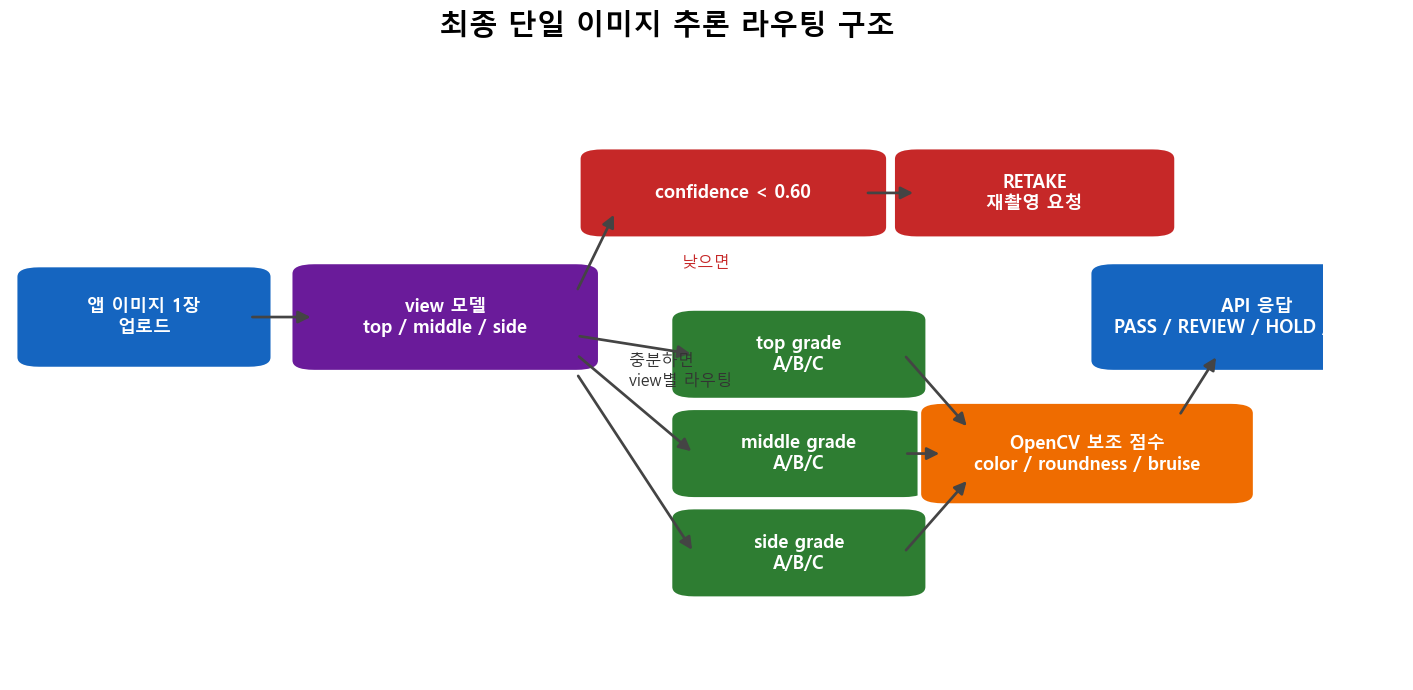

In [7]:
fig, ax = plt.subplots(figsize=(13, 6.2))
ax.axis('off')

add_box(ax, '앱 이미지 1장\n업로드', 0.10, 0.58, 0.16, 0.13, COLORS['blue'])
add_box(ax, 'view 모델\ntop / middle / side', 0.33, 0.58, 0.20, 0.14, COLORS['purple'])
add_box(ax, 'confidence < 0.60', 0.55, 0.78, 0.20, 0.11, COLORS['red'])
add_box(ax, 'RETAKE\n재촬영 요청', 0.78, 0.78, 0.18, 0.11, COLORS['red'])
add_box(ax, 'top grade\nA/B/C', 0.60, 0.52, 0.16, 0.11, COLORS['green'])
add_box(ax, 'middle grade\nA/B/C', 0.60, 0.36, 0.16, 0.11, COLORS['green'])
add_box(ax, 'side grade\nA/B/C', 0.60, 0.20, 0.16, 0.11, COLORS['green'])
add_box(ax, 'OpenCV 보조 점수\ncolor / roundness / bruise', 0.82, 0.36, 0.22, 0.13, COLORS['orange'])
add_box(ax, 'API 응답\nPASS / REVIEW / HOLD / RETAKE', 0.95, 0.58, 0.22, 0.14, COLORS['blue'])

for start, end in [
    ((0.18, 0.58), (0.23, 0.58)), ((0.43, 0.62), (0.46, 0.75)), ((0.65, 0.78), (0.69, 0.78)),
    ((0.43, 0.55), (0.52, 0.52)), ((0.43, 0.52), (0.52, 0.36)), ((0.43, 0.49), (0.52, 0.20)),
    ((0.68, 0.52), (0.73, 0.40)), ((0.68, 0.36), (0.71, 0.36)), ((0.68, 0.20), (0.73, 0.32)),
    ((0.89, 0.42), (0.92, 0.52)),
]:
    add_arrow(ax, start, end)

ax.text(0.51, 0.66, '낮으면', fontsize=9, color=COLORS['red'])
ax.text(0.47, 0.47, '충분하면\nview별 라우팅', fontsize=9, color='#333')
ax.set_title('최종 단일 이미지 추론 라우팅 구조', fontsize=16, weight='bold', pad=12)
savefig('06_final_model_routing.png')
plt.show()

## 8. 실험별 성능 비교

실패한 실험은 최종 구조가 왜 필요한지 보여주는 비교 기준입니다. 아래 그래프는 각 실험의 task별 성능 평균입니다.

saved: visuals\07_experiment_performance_comparison.png


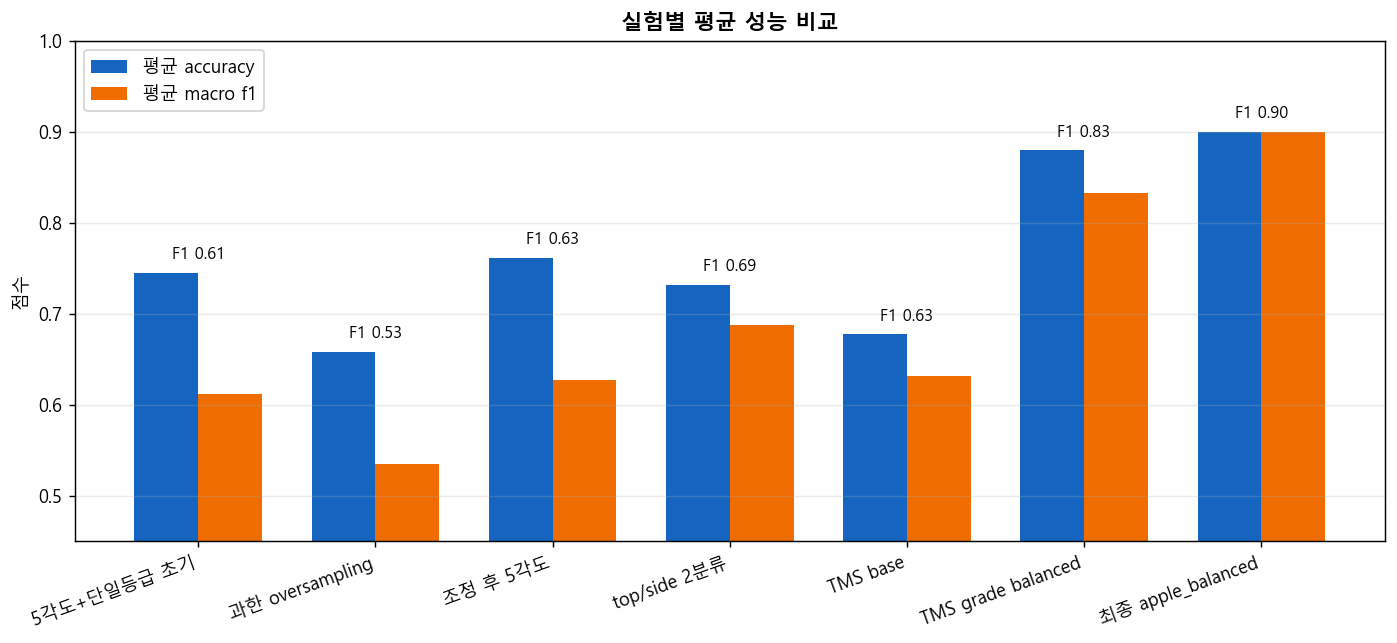

,experiment,mean_accuracy,mean_macro_f1
0,5각도+단일등급 초기,0.745000,0.611900
1,과한 oversampling,0.658200,0.534700
2,조정 후 5각도,0.761250,0.627100
3,top/side 2분류,0.731933,0.687233
4,TMS base,0.677225,0.631475
5,TMS grade balanced,0.879400,0.832350
6,최종 apple_balanced,0.899800,0.899375


In [8]:
experiments = pd.DataFrame([
    ['5각도+단일등급 초기', 'view/angle', 0.8581, 0.6167], ['5각도+단일등급 초기', 'grade', 0.6319, 0.6071],
    ['과한 oversampling', 'view/angle', 0.7395, 0.5195], ['과한 oversampling', 'grade', 0.5769, 0.5499],
    ['조정 후 5각도', 'view/angle', 0.8636, 0.6235], ['조정 후 5각도', 'grade', 0.6589, 0.6307],
    ['top/side 2분류', 'view', 0.8773, 0.7834], ['top/side 2분류', 'top grade', 0.6284, 0.6005], ['top/side 2분류', 'side grade', 0.6901, 0.6778],
    ['TMS base', 'view', 0.8777, 0.7033], ['TMS base', 'top grade', 0.6058, 0.5801], ['TMS base', 'middle grade', 0.5986, 0.5885], ['TMS base', 'side grade', 0.6268, 0.6540],
    ['TMS grade balanced', 'view', 0.8800, 0.6924], ['TMS grade balanced', 'top grade', 0.8301, 0.8306], ['TMS grade balanced', 'middle grade', 0.9061, 0.9045], ['TMS grade balanced', 'side grade', 0.9014, 0.9019],
    ['최종 apple_balanced', 'view', 0.9177, 0.9162], ['최종 apple_balanced', 'top grade', 0.8605, 0.8612], ['최종 apple_balanced', 'middle grade', 0.9074, 0.9065], ['최종 apple_balanced', 'side grade', 0.9136, 0.9136],
], columns=['experiment', 'task', 'accuracy', 'macro_f1'])

order = ['5각도+단일등급 초기', '과한 oversampling', '조정 후 5각도', 'top/side 2분류', 'TMS base', 'TMS grade balanced', '최종 apple_balanced']
summary = experiments.groupby('experiment').agg(mean_accuracy=('accuracy', 'mean'), mean_macro_f1=('macro_f1', 'mean')).reindex(order).reset_index()

fig, ax = plt.subplots(figsize=(13, 5))
x = np.arange(len(summary))
ax.bar(x - 0.18, summary['mean_accuracy'], 0.36, label='평균 accuracy', color=COLORS['blue'])
ax.bar(x + 0.18, summary['mean_macro_f1'], 0.36, label='평균 macro f1', color=COLORS['orange'])
ax.set_xticks(x)
ax.set_xticklabels(summary['experiment'], rotation=20, ha='right')
ax.set_ylim(0.45, 1.0)
ax.set_ylabel('점수')
ax.set_title('실험별 평균 성능 비교', weight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.25)
for i, row in summary.iterrows():
    ax.text(i, max(row['mean_accuracy'], row['mean_macro_f1']) + 0.015, f"F1 {row['mean_macro_f1']:.2f}", ha='center', fontsize=9)
savefig('07_experiment_performance_comparison.png')
plt.show()
summary

## 9. 최종 모델별 성능

최종 모델은 view 모델 1개와 grade 모델 3개입니다.

saved: visuals\08_final_model_metrics.png


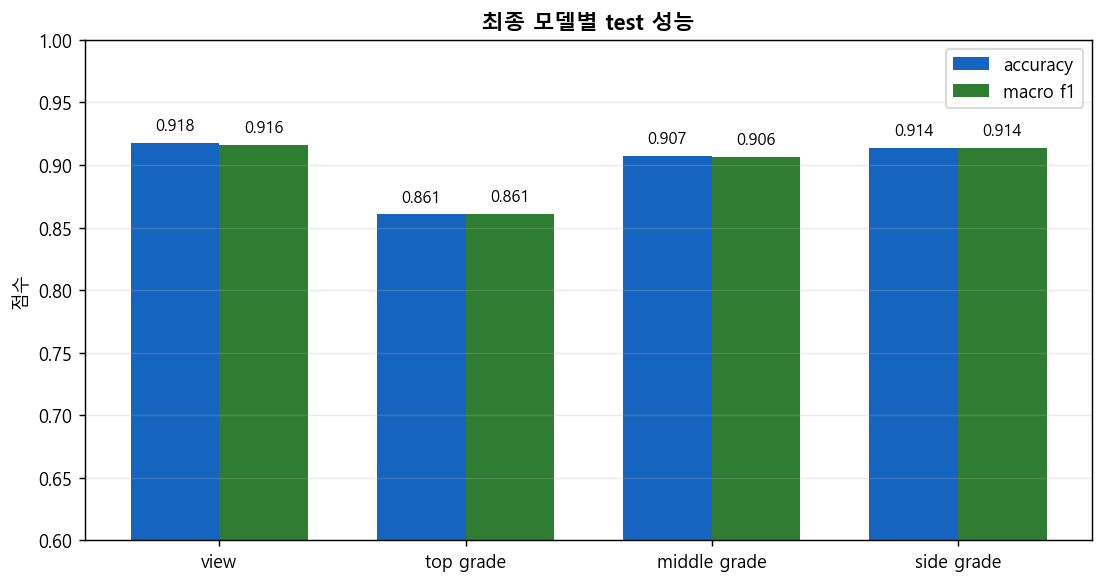

In [9]:
final_metrics = pd.DataFrame([
    ['view', 0.9177, 0.9162],
    ['top grade', 0.8605, 0.8612],
    ['middle grade', 0.9074, 0.9065],
    ['side grade', 0.9136, 0.9136],
], columns=['model', 'accuracy', 'macro_f1'])

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(final_metrics))
ax.bar(x - 0.18, final_metrics['accuracy'], 0.36, label='accuracy', color=COLORS['blue'])
ax.bar(x + 0.18, final_metrics['macro_f1'], 0.36, label='macro f1', color=COLORS['green'])
ax.set_xticks(x)
ax.set_xticklabels(final_metrics['model'])
ax.set_ylim(0.6, 1.0)
ax.set_ylabel('점수')
ax.set_title('최종 모델별 test 성능', weight='bold')
ax.grid(axis='y', alpha=0.25)
ax.legend()
for i, row in final_metrics.iterrows():
    ax.text(i - 0.18, row['accuracy'] + 0.01, f"{row['accuracy']:.3f}", ha='center', fontsize=9)
    ax.text(i + 0.18, row['macro_f1'] + 0.01, f"{row['macro_f1']:.3f}", ha='center', fontsize=9)
savefig('08_final_model_metrics.png')
plt.show()

## 10. 최종 confusion matrix

confusion matrix는 어떤 class끼리 헷갈리는지 보여줍니다.

saved: visuals\09_final_confusion_matrices.png


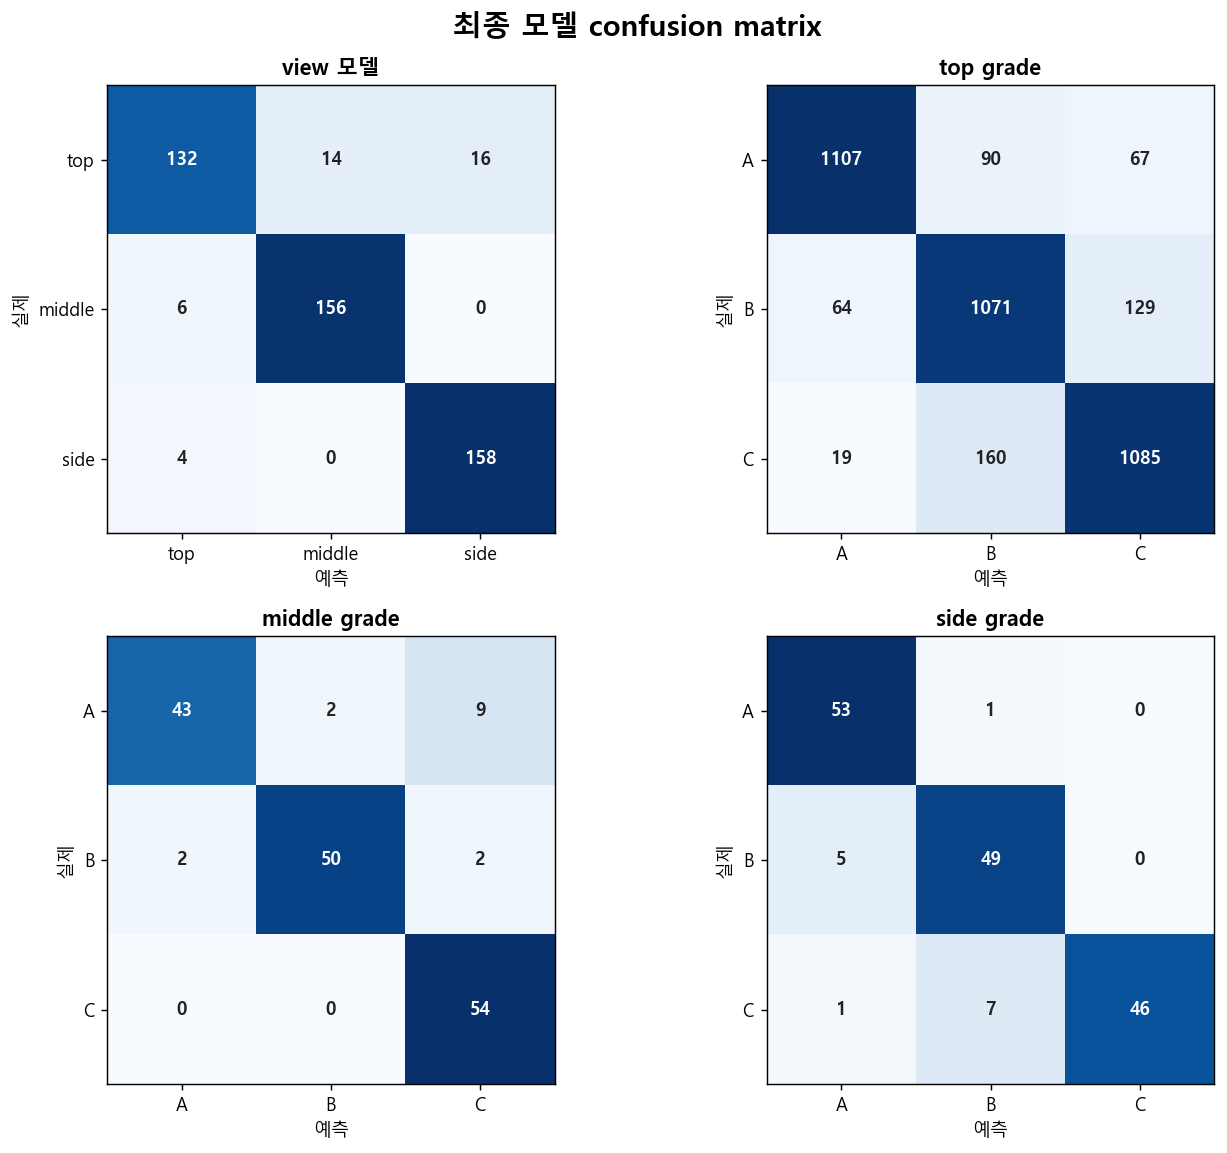

In [10]:
confusions = {
    'view 모델': (np.array([[132, 14, 16], [6, 156, 0], [4, 0, 158]]), ['top', 'middle', 'side']),
    'top grade': (np.array([[1107, 90, 67], [64, 1071, 129], [19, 160, 1085]]), ['A', 'B', 'C']),
    'middle grade': (np.array([[43, 2, 9], [2, 50, 2], [0, 0, 54]]), ['A', 'B', 'C']),
    'side grade': (np.array([[53, 1, 0], [5, 49, 0], [1, 7, 46]]), ['A', 'B', 'C']),
}

fig, axes = plt.subplots(2, 2, figsize=(11, 9))
for ax, (title, (cm, labels)) in zip(axes.ravel(), confusions.items()):
    ax.imshow(cm, cmap='Blues')
    ax.set_title(title, weight='bold')
    ax.set_xticks(np.arange(len(labels)))
    ax.set_yticks(np.arange(len(labels)))
    ax.set_xticklabels(labels)
    ax.set_yticklabels(labels)
    ax.set_xlabel('예측')
    ax.set_ylabel('실제')
    threshold = cm.max() / 2
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            color = 'white' if cm[i, j] > threshold else '#222'
            ax.text(j, i, f'{cm[i, j]}', ha='center', va='center', color=color, fontsize=10, weight='bold')
fig.suptitle('최종 모델 confusion matrix', fontsize=16, weight='bold')
fig.tight_layout()
savefig('09_final_confusion_matrices.png')
plt.show()

## 11. class별 precision/recall/f1

불균형 데이터에서는 accuracy 하나만으로 판단하기 어렵습니다. view 모델은 middle/side recall을 함께 봐야 합니다.

saved: visuals\10_class_level_metrics.png


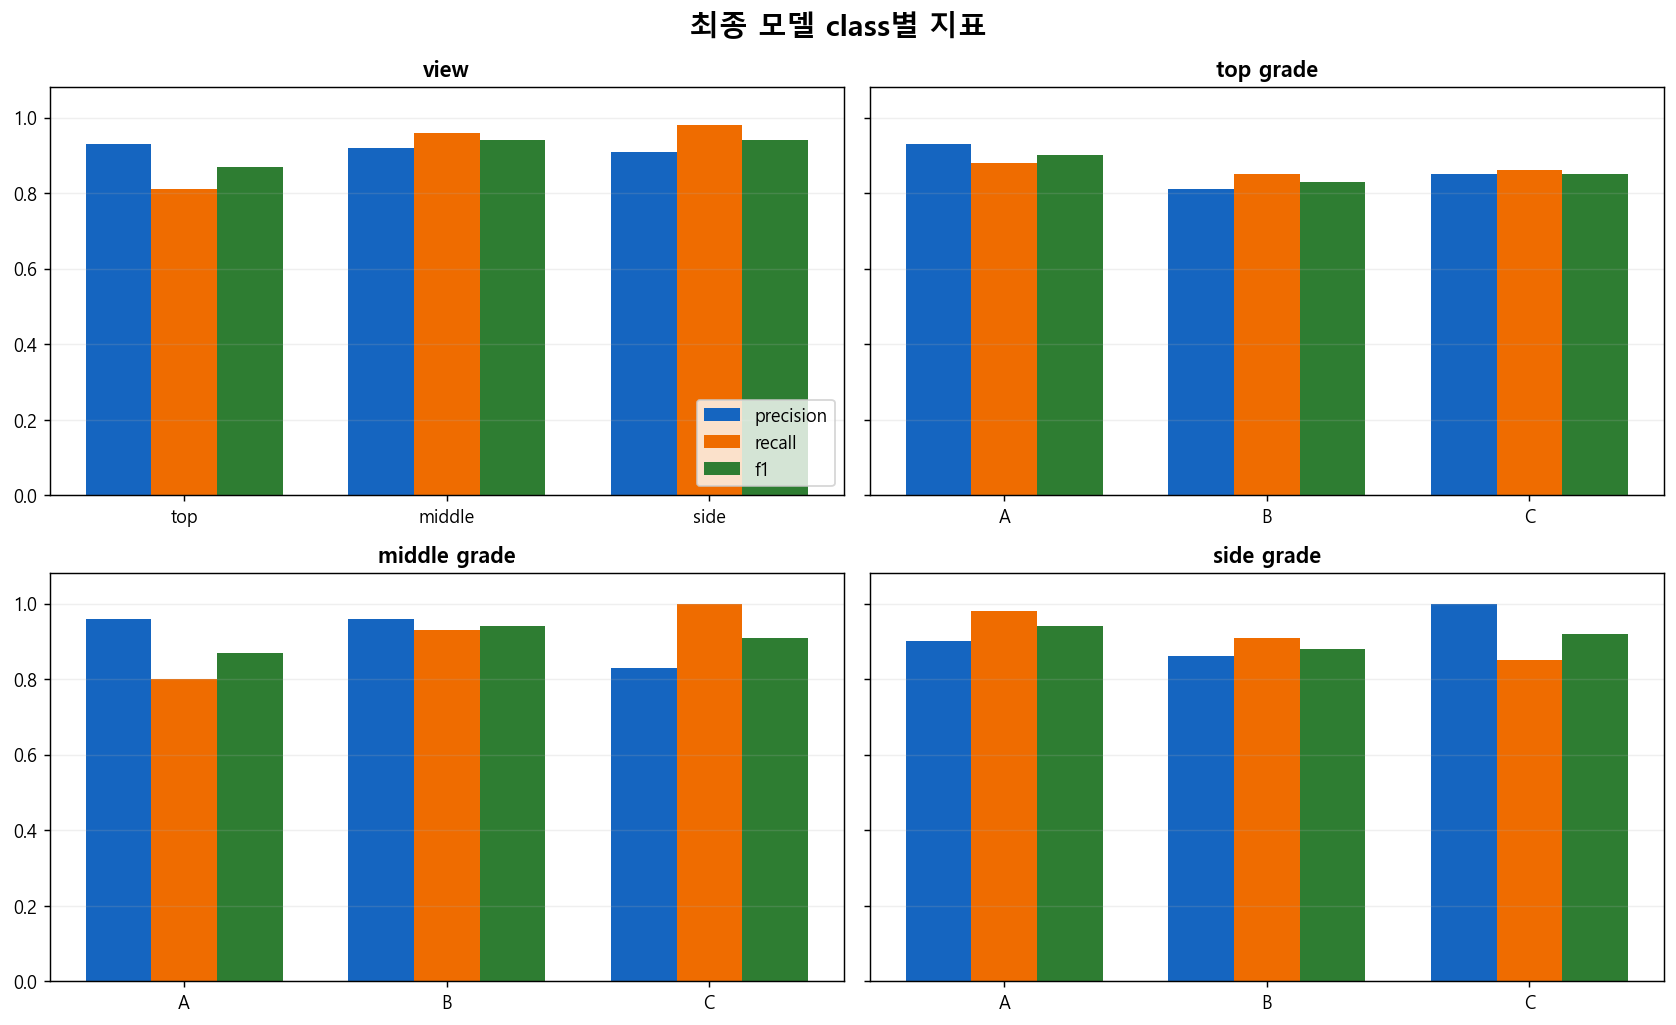

In [11]:
class_metrics = pd.DataFrame([
    ['view', 'top', 0.93, 0.81, 0.87, 162], ['view', 'middle', 0.92, 0.96, 0.94, 162], ['view', 'side', 0.91, 0.98, 0.94, 162],
    ['top grade', 'A', 0.93, 0.88, 0.90, 1264], ['top grade', 'B', 0.81, 0.85, 0.83, 1264], ['top grade', 'C', 0.85, 0.86, 0.85, 1264],
    ['middle grade', 'A', 0.96, 0.80, 0.87, 54], ['middle grade', 'B', 0.96, 0.93, 0.94, 54], ['middle grade', 'C', 0.83, 1.00, 0.91, 54],
    ['side grade', 'A', 0.90, 0.98, 0.94, 54], ['side grade', 'B', 0.86, 0.91, 0.88, 54], ['side grade', 'C', 1.00, 0.85, 0.92, 54],
], columns=['model', 'class', 'precision', 'recall', 'f1', 'support'])

fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharey=True)
for ax, model in zip(axes.ravel(), ['view', 'top grade', 'middle grade', 'side grade']):
    part = class_metrics[class_metrics['model'] == model]
    x = np.arange(len(part))
    ax.bar(x - 0.25, part['precision'], 0.25, label='precision', color=COLORS['blue'])
    ax.bar(x, part['recall'], 0.25, label='recall', color=COLORS['orange'])
    ax.bar(x + 0.25, part['f1'], 0.25, label='f1', color=COLORS['green'])
    ax.set_xticks(x)
    ax.set_xticklabels(part['class'])
    ax.set_title(model, weight='bold')
    ax.set_ylim(0, 1.08)
    ax.grid(axis='y', alpha=0.2)
axes[0, 0].legend(loc='lower right')
fig.suptitle('최종 모델 class별 지표', fontsize=16, weight='bold')
fig.tight_layout()
savefig('10_class_level_metrics.png')
plt.show()

## 12. 품종별/세부 각도별 성능

품종과 세부 각도에 따라 성능 차이가 남아 있습니다. 이후 운영 데이터가 쌓이면 이 기준으로 보강 대상을 정할 수 있습니다.

saved: visuals\11_grouped_performance.png


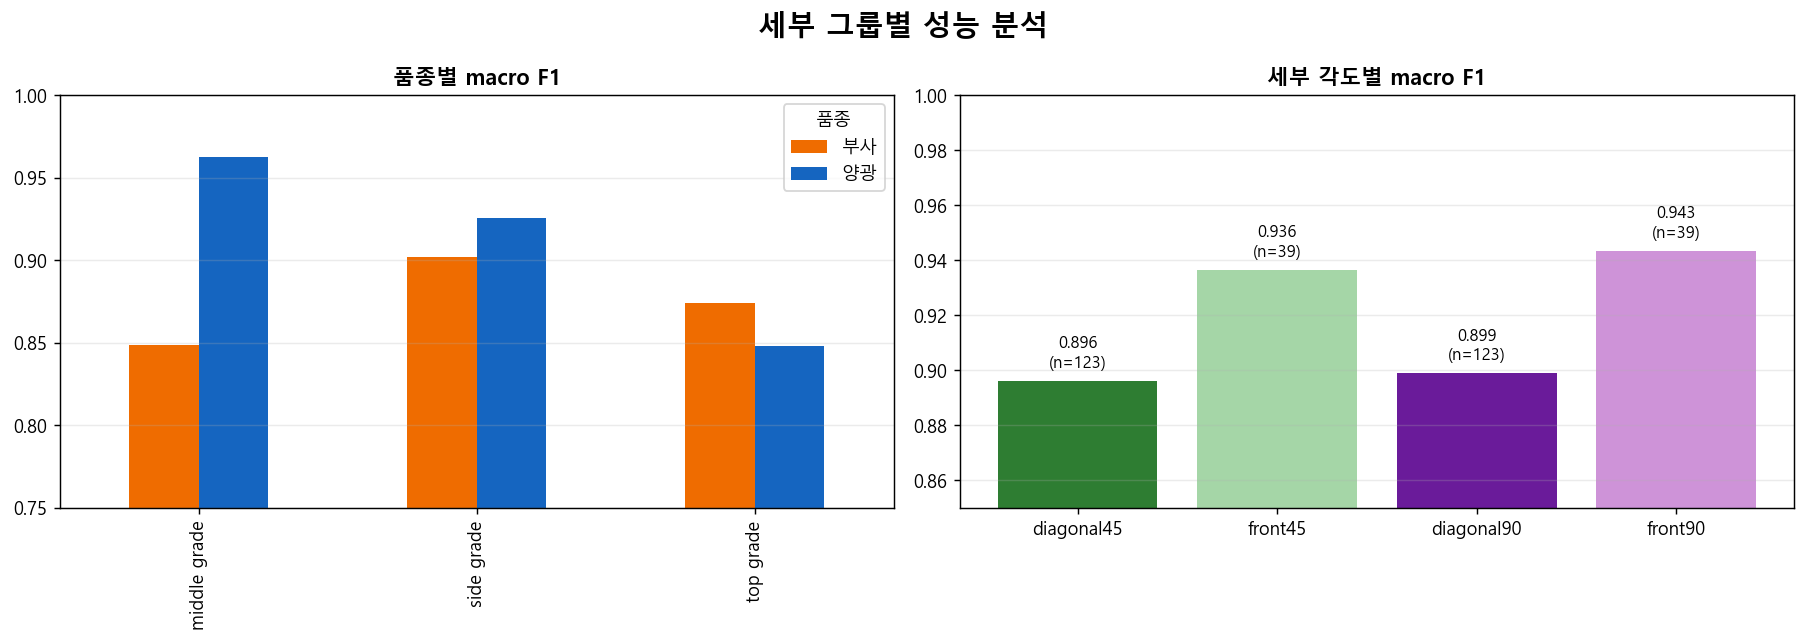

In [12]:
variety_metrics = pd.DataFrame([
    ['top grade', '양광', 1896, 0.8481, 0.8481], ['top grade', '부사', 1896, 0.8729, 0.8741],
    ['middle grade', '양광', 81, 0.9630, 0.9629], ['middle grade', '부사', 81, 0.8519, 0.8485],
    ['side grade', '양광', 81, 0.9259, 0.9257], ['side grade', '부사', 81, 0.9012, 0.9017],
], columns=['model', 'variety', 'count', 'accuracy', 'macro_f1'])
angle_detail_metrics = pd.DataFrame([
    ['middle grade', 'diagonal45', 123, 0.8943, 0.8961], ['middle grade', 'front45', 39, 0.9487, 0.9365],
    ['side grade', 'diagonal90', 123, 0.9024, 0.8988], ['side grade', 'front90', 39, 0.9487, 0.9434],
], columns=['model', 'angle_detail', 'count', 'accuracy', 'macro_f1'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
variety_metrics.pivot(index='model', columns='variety', values='macro_f1').plot(kind='bar', ax=axes[0], color=[COLORS['orange'], COLORS['blue']])
axes[0].set_title('품종별 macro F1', weight='bold')
axes[0].set_ylim(0.75, 1.0)
axes[0].set_xlabel('')
axes[0].grid(axis='y', alpha=0.25)
axes[0].legend(title='품종')

axes[1].bar(angle_detail_metrics['angle_detail'], angle_detail_metrics['macro_f1'], color=[COLORS['green'], COLORS['light_green'], COLORS['purple'], '#CE93D8'])
axes[1].set_title('세부 각도별 macro F1', weight='bold')
axes[1].set_ylim(0.85, 1.0)
axes[1].grid(axis='y', alpha=0.25)
for i, row in angle_detail_metrics.iterrows():
    axes[1].text(i, row['macro_f1'] + 0.005, f"{row['macro_f1']:.3f}\n(n={row['count']})", ha='center', fontsize=9)
fig.suptitle('세부 그룹별 성능 분석', fontsize=16, weight='bold')
fig.tight_layout()
savefig('11_grouped_performance.png')
plt.show()

## 13. 신선도 점수와 최종 판정 흐름

등급 모델 결과만 사용하는 것이 아니라 OpenCV 보조 점수와 confidence threshold를 함께 사용해 최종 판정을 만듭니다.

saved: visuals\12_freshness_decision_flow.png


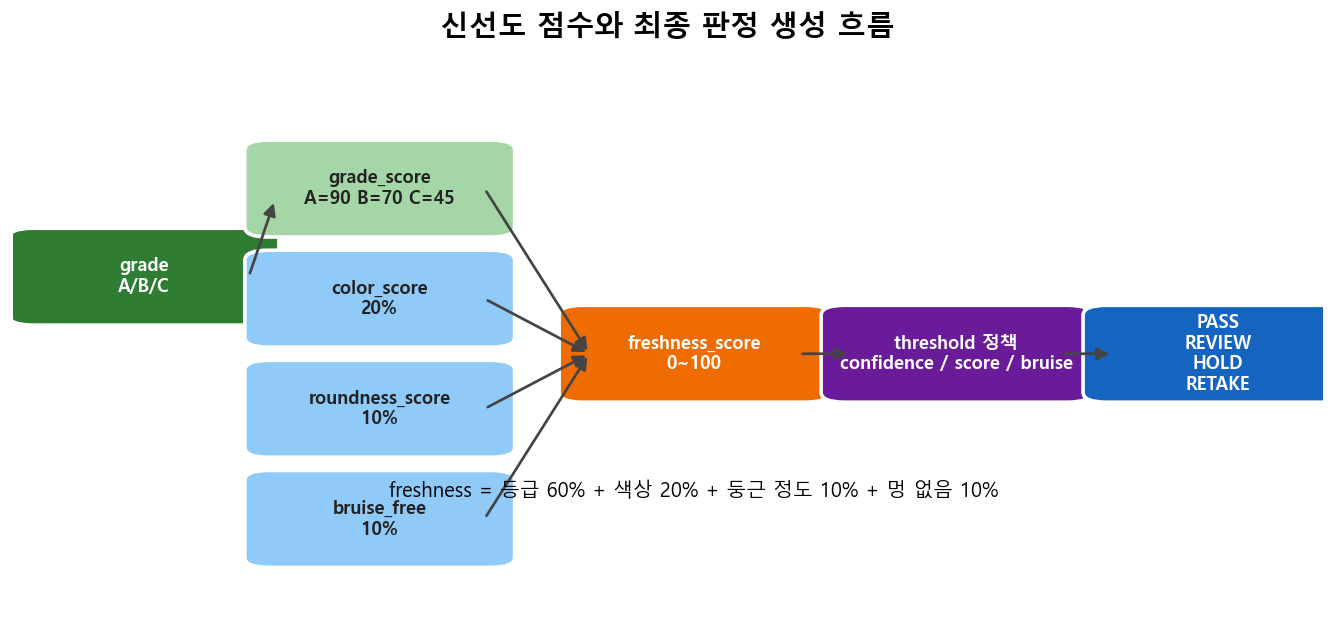

In [13]:
fig, ax = plt.subplots(figsize=(13, 5.5))
ax.axis('off')
steps = [
    ('grade\nA/B/C', 0.10, 0.60, COLORS['green']),
    ('grade_score\nA=90 B=70 C=45', 0.28, 0.76, COLORS['light_green']),
    ('color_score\n20%', 0.28, 0.56, COLORS['light_blue']),
    ('roundness_score\n10%', 0.28, 0.36, COLORS['light_blue']),
    ('bruise_free\n10%', 0.28, 0.16, COLORS['light_blue']),
    ('freshness_score\n0~100', 0.52, 0.46, COLORS['orange']),
    ('threshold 정책\nconfidence / score / bruise', 0.72, 0.46, COLORS['purple']),
    ('PASS\nREVIEW\nHOLD\nRETAKE', 0.92, 0.46, COLORS['blue']),
]
for text, x, y, color in steps:
    text_color = '#222' if color in [COLORS['light_green'], COLORS['light_blue']] else 'white'
    add_box(ax, text, x, y, 0.17, 0.14, color, text_color=text_color)
for start in [(0.36, 0.76), (0.36, 0.56), (0.36, 0.36), (0.36, 0.16)]:
    add_arrow(ax, start, (0.44, 0.46))
add_arrow(ax, (0.18, 0.60), (0.20, 0.74))
add_arrow(ax, (0.60, 0.46), (0.64, 0.46))
add_arrow(ax, (0.80, 0.46), (0.84, 0.46))
ax.text(0.52, 0.20, 'freshness = 등급 60% + 색상 20% + 둥근 정도 10% + 멍 없음 10%', ha='center', fontsize=11)
ax.set_title('신선도 점수와 최종 판정 생성 흐름', fontsize=16, weight='bold', pad=12)
savefig('12_freshness_decision_flow.png')
plt.show()

## 14. API 응답과 앱 화면 분기

앱에서는 `action_required`를 기준으로 화면을 나누면 구현이 단순합니다.

saved: visuals\13_api_app_branching.png


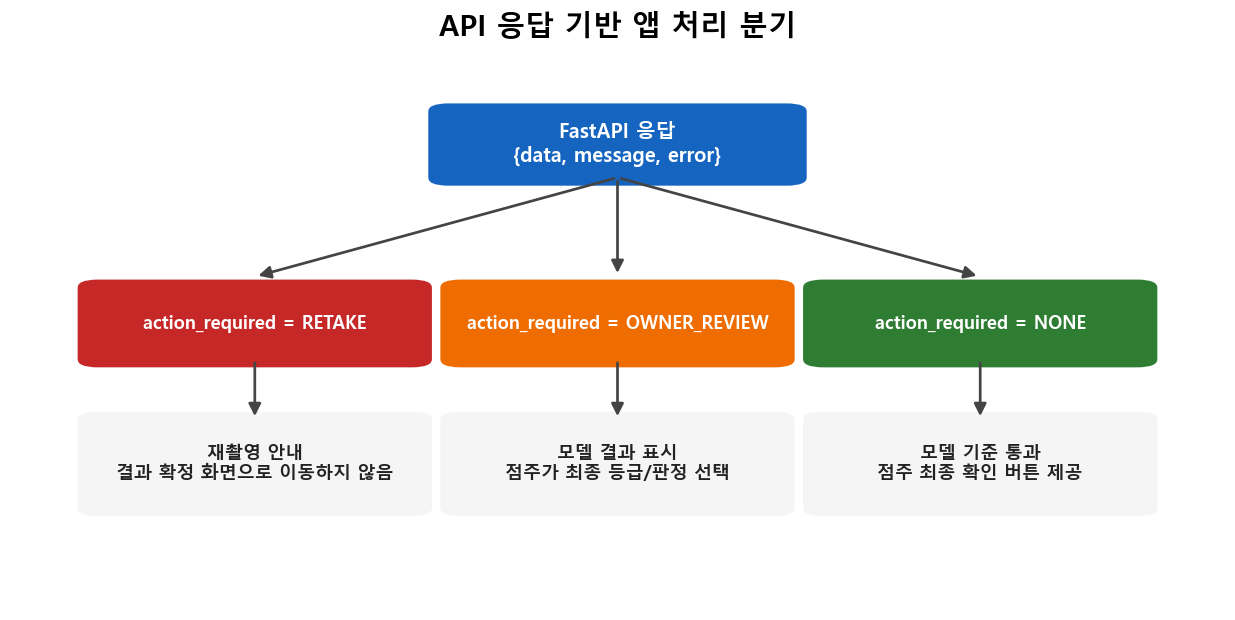

In [14]:
fig, ax = plt.subplots(figsize=(12, 5.5))
ax.axis('off')
branches = [
    ('action_required = RETAKE', '재촬영 안내\n결과 확정 화면으로 이동하지 않음', COLORS['red'], 0.20),
    ('action_required = OWNER_REVIEW', '모델 결과 표시\n점주가 최종 등급/판정 선택', COLORS['orange'], 0.50),
    ('action_required = NONE', '모델 기준 통과\n점주 최종 확인 버튼 제공', COLORS['green'], 0.80),
]
add_box(ax, 'FastAPI 응답\n{data, message, error}', 0.50, 0.84, 0.28, 0.12, COLORS['blue'], fontsize=11)
for title, desc, color, x in branches:
    add_box(ax, title, x, 0.515, 0.26, 0.13, color, fontsize=10)
    add_box(ax, desc, x, 0.26, 0.26, 0.16, '#F5F5F5', text_color='#222', fontsize=10)
    add_arrow(ax, (0.50, 0.78), (x, 0.60))
    add_arrow(ax, (x, 0.45), (x, 0.34))
ax.set_title('API 응답 기반 앱 처리 분기', fontsize=16, weight='bold', pad=12)
savefig('13_api_app_branching.png')
plt.show()

## 15. 생성되는 이미지 파일

노트를 실행하면 `Note/visuals/` 폴더에 문서나 발표 자료에 넣을 수 있는 PNG 파일이 생성됩니다.

In [15]:
for path in sorted(OUTPUT_DIR.glob('*.png')):
    print(path)

visuals\01_data_folder_structure.png
visuals\02_json_label_mapping.png
visuals\03_label_mappings.png
visuals\04_group_split_vs_random_split.png
visuals\05_view_distribution_and_balancing.png
visuals\06_final_model_routing.png
visuals\07_experiment_performance_comparison.png
visuals\08_final_model_metrics.png
visuals\09_final_confusion_matrices.png
visuals\10_class_level_metrics.png
visuals\11_grouped_performance.png
visuals\12_freshness_decision_flow.png
visuals\13_api_app_branching.png


## 16. 발표/문서에 넣기 좋은 순서

1. `01_data_folder_structure.png`: 원본 데이터 구조
2. `02_json_label_mapping.png`: JSON 라벨 사용 방식
3. `03_label_mappings.png`: A/B/C 및 top/middle/side 매핑
4. `04_group_split_vs_random_split.png`: 데이터 누수 방지 split
5. `05_view_distribution_and_balancing.png`: 데이터 불균형과 balanced train
6. `06_final_model_routing.png`: 최종 모델 라우팅 구조
7. `07_experiment_performance_comparison.png`: 실패 실험과 최종 모델 비교
8. `08_final_model_metrics.png`: 최종 모델별 성능
9. `09_final_confusion_matrices.png`: 최종 confusion matrix
10. `10_class_level_metrics.png`: class별 precision/recall/f1
11. `11_grouped_performance.png`: 품종/세부 각도별 성능
12. `12_freshness_decision_flow.png`: 신선도 점수와 판정 정책
13. `13_api_app_branching.png`: 앱 처리 분기